# ¿Cuál es la mejor tarifa?

Soy analista de datos para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Voy a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tengo los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Mi trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [1]:
# Cargar todas las librerías

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística y pruebas de hipótesis
from scipy import stats

# Configuración de estilo para gráficos
plt.style.use('seaborn-whitegrid')
sns.set_palette('deep')

# Opciones de pandas para mostrar más columnas y filas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

calls_path = '/datasets/megaline_calls.csv'
internet_path = '/datasets/megaline_internet.csv'
messages_path = '/datasets/megaline_messages.csv'
plans_path = '/datasets/megaline_plans.csv'
users_path = '/datasets/megaline_users.csv'

# Lectura de los archivos
calls = pd.read_csv(calls_path)
internet = pd.read_csv(internet_path)
messages = pd.read_csv(messages_path)
plans = pd.read_csv(plans_path)
users = pd.read_csv(users_path)

# tamaños y primeras filas
print("calls:", calls.shape)
print("internet:", internet.shape)
print("messages:", messages.shape)
print("plans:", plans.shape)
print("users:", users.shape)

# Vista de cada tabla
display(calls.head())
display(internet.head())
display(messages.head())
display(plans.head())
display(users.head())

calls: (137735, 4)
internet: (104825, 4)
messages: (76051, 3)
plans: (2, 8)
users: (500, 8)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


## Preparar los datos

### 2.3. Preparar los datos
Los datos se dividen en varias tablas (users, calls, messages, internet, plans).  
Cada tabla fue explorada para entender su estructura y detectar posibles correcciones necesarias.

### 2.4. Tarifas
Observaciones sobre el DataFrame `plans`:
- El DataFrame contiene **2 filas** (Surf y Ultimate) y **8 columnas**.  
- No hay valores nulos en ninguna columna.  
- Los tipos de datos son correctos: enteros para cuotas y límites, flotantes para costos por unidad, y texto para el nombre del plan.  
- La columna `plan_name` está en minúsculas (`surf`, `ultimate`), lo cual conviene normalizar (ej. capitalizar) para evitar inconsistencias en merges posteriores.  
- La columna `mb_per_month_included` representa el tráfico incluido en MB (15360 MB = 15 GB, 30720 MB = 30 GB). Esto debe tenerse en cuenta al calcular excedentes.  
- Los costos extra (`usd_per_message`, `usd_per_minute`, `usd_per_gb`) están expresados en dólares y son distintos entre planes (ej. GB extra cuesta 10 USD en Surf y 7 USD en Ultimate).  

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

print("=== Información del DataFrame plans ===")
plans.info()

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(plans.isna().sum())

# Resumen estadístico de las columnas numéricas
print("\nResumen estadístico:")
display(plans.describe())

# Vista rápida de todas las filas
print("\nContenido completo del DataFrame:")
display(plans)

=== Información del DataFrame plans ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes

Valores nulos por columna:
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Resumen estadís

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000
max,1000.000000,30720.000000,3000.000000,70.000000,10.00000,0.030000,0.030000



Contenido completo del DataFrame:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [4]:
# Imprime una muestra de los datos para las tarifas

# Mostrar las primeras filas 
print("Muestra de las tarifas disponibles:\n")
display(plans.head())

# mostrar todas las filas directamente
print("\nContenido completo del DataFrame de tarifas:\n")
display(plans)

Muestra de las tarifas disponibles:



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate



Contenido completo del DataFrame de tarifas:



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Los datos estan cargados correctamente

## Corregir datos


La tabla `plans` no requiere correcciones de valores nulos ni de tipos de datos:
- Todas las columnas están completas (sin valores faltantes).
- Los tipos de datos son correctos: enteros para cuotas y límites, flotantes para costos por unidad, y texto para el nombre del plan.
- Los valores de `mb_per_month_included` están expresados en MB (15 360 MB = 15 GB, 30 720 MB = 30 GB), lo cual se tendrá en cuenta en los cálculos de excedentes.

La única mejora aplicada es la **normalización de los nombres de los planes** para evitar inconsistencias en merges posteriores:

```python
# Normalizar nombres de planes
plans['plan_name'] = plans['plan_name'].str.capitalize()

## Enriquecer los datos

- Se agregó la columna gb_included para expresar el tráfico incluido en GB (más claro que MB).
- Se calcularon costos efectivos por minuto, SMS y GB dentro del paquete.
- Se normalizó plan_name para evitar inconsistencias en merges y asegurar que el mapeo funcione.
- Se creó la columna plan_type para clasificar los planes como Económico (Surf) y Premium (Ultimate).


In [5]:
#  Enriquecer los datos – Tabla plans

# GB incluidos (para visualización más clara)
plans['gb_included'] = plans['mb_per_month_included'] / 1024

# Costo efectivo por minuto, SMS y GB dentro del paquete
plans['cost_per_min_included'] = plans['usd_monthly_pay'] / plans['minutes_included']
plans['cost_per_sms_included'] = plans['usd_monthly_pay'] / plans['messages_included']
plans['cost_per_gb_included'] = plans['usd_monthly_pay'] / plans['gb_included']

# Normalizar plan_name (evita inconsistencias en merges y mapeos)
plans['plan_name'] = plans['plan_name'].str.capitalize()

# Clasificación del plan (económico vs premium)
plans['plan_type'] = plans['plan_name'].map({
    'Surf': 'Económico',
    'Ultimate': 'Premium'
})

# Vista final del DataFrame enriquecido
print("DataFrame de tarifas enriquecido:")
display(plans)

DataFrame de tarifas enriquecido:


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_included,cost_per_min_included,cost_per_sms_included,cost_per_gb_included,plan_type
0,50,15360,500,20,10,0.03,0.03,Surf,15.0,0.040000,0.40,1.333333,Económico
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30.0,0.023333,0.07,2.333333,Premium


## Usuarios/as

In [6]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

print("=== Información del DataFrame users ===")
users.info()

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(users.isna().sum())

# Conteo de duplicados
print("\nDuplicados exactos:", users.duplicated().sum())

# Resumen estadístico de las columnas numéricas 
print("\nResumen estadístico:")
display(users.describe())

# Vista rápida de las primeras filas
print("\nMuestra de datos de usuarios:")
display(users.head())

=== Información del DataFrame users ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB

Valores nulos por columna:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

Duplicados exactos: 0

Resumen estadístico:


,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000



Muestra de datos de usuarios:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [7]:
# Imprime una muestra de datos para usuarios

# Mostrar las primeras filas
print("Primeras filas del DataFrame users:\n")
display(users.head())

# muestra aleatoria de usuarios
print("\nMuestra aleatoria de usuarios:\n")
display(users.sample(5, random_state=42))

Primeras filas del DataFrame users:



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN



Muestra aleatoria de usuarios:



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
361,1361,Jacelyn,Hoffman,45,"Birmingham-Hoover, AL MSA",2018-04-14,surf,NaN
73,1073,Grady,Crawford,30,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-04-06,surf,NaN
374,1374,Ching,Watts,55,"Louisville/Jefferson County, KY-IN MSA",2018-02-14,surf,NaN
155,1155,Claude,Hahn,19,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-02-21,ultimate,NaN
104,1104,Thurman,Stephens,20,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-12-23,ultimate,NaN



El DataFrame users está bien estructurado, pero requiere correcciones menores: convertir fechas a datetime, tipificar variables categóricas y estandarizar los nombres de planes. Los nulos en churn_date son esperados y no necesitan eliminación.
problemas detectados:
- Fechas como texto (object) → deben convertirse a datetime.
- Planes y ciudades como texto (object) → mejor convertirlos a category para optimizar y facilitar análisis.
- Valores nulos en churn_date → no es un error, pero debemos documentar que significa “cliente activo”.
- Formato de nombres de planes → están en minúsculas, conviene estandarizar (Surf, Ultimate) para consistencia con el DataFrame plans.


### Corregir los datos

- Fechas: reg_date y churn_date convertidas a datetime64.
- Planes: normalizados a Surf y Ultimate antes de convertir a category, lo que asegura consistencia en merges posteriores y mejor rendimiento/memoria.
- City: convertida a category para optimizar almacenamiento y facilitar agrupaciones.
- Nueva columna status: indica si el usuario está activo o inactivo según churn_date.


In [8]:
# 2.7.1. Corregir los datos – Tabla users

# Convertir fechas a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

# Normalizar nombres de planes (mientras aún son strings)
users['plan'] = users['plan'].str.strip().str.capitalize()

# Convertir plan y city a categóricos (después de normalizar)
users['plan'] = users['plan'].astype('category')
users['city'] = users['city'].astype('category')

# Crear columna adicional: estado del cliente (activo/inactivo)
users['status'] = users['churn_date'].apply(lambda x: 'Inactivo' if pd.notna(x) else 'Activo')

# Vista final tras correcciones
print("DataFrame users corregido:")
display(users.info())
display(users.head())

DataFrame users corregido:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    category      
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    category      
 7   churn_date  34 non-null     datetime64[ns]
 8   status      500 non-null    object        
dtypes: category(2), datetime64[ns](2), int64(2), object(3)
memory usage: 31.2+ KB


None

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,status
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,Ultimate,NaT,Activo
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,Surf,NaT,Activo
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,Surf,NaT,Activo
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,Surf,NaT,Activo
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,Surf,NaT,Activo


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [9]:
# 1.7.2 Enriquecer los datos de usuarios
# Año y mes de registro
users['reg_year'] = users['reg_date'].dt.year
users['reg_month'] = users['reg_date'].dt.month

# Antigüedad del cliente en meses
# Si el cliente está activo, calculamos hasta diciembre 2018.
end_date = pd.to_datetime("2018-12-31")
users['end_date'] = users['churn_date'].fillna(end_date)
users['tenure_months'] = ((users['end_date'] - users['reg_date']) / np.timedelta64(1, 'M')).round().astype(int)

# Agrupación de edad
bins = [0, 29, 44, 59, 100]
labels = ['Joven (18-29)', 'Adulto (30-44)', 'Adulto mayor (45-59)', 'Senior (60+)']
users['age_group'] = pd.cut(users['age'], bins=bins, labels=labels, right=True)

# Columna booleana de estado
users['is_active'] = users['status'].apply(lambda x: True if x == 'Activo' else False)

# Vista final del DataFrame enriquecido
print("DataFrame users enriquecido:")
display(users.head())

DataFrame users enriquecido:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,status,reg_year,reg_month,end_date,tenure_months,age_group,is_active
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,Ultimate,NaT,Activo,2018,12,2018-12-31,0,Adulto mayor (45-59),True
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,Surf,NaT,Activo,2018,8,2018-12-31,5,Joven (18-29),True
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,Surf,NaT,Activo,2018,10,2018-12-31,2,Adulto (30-44),True
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,Surf,NaT,Activo,2018,1,2018-12-31,11,Adulto mayor (45-59),True
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,Surf,NaT,Activo,2018,5,2018-12-31,7,Adulto (30-44),True


## Llamadas

In [10]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas


# Información general del DataFrame de llamadas

print("=== Información del DataFrame calls ===")
calls.info()

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(calls.isna().sum())

# Conteo de duplicados
print("\nDuplicados exactos:", calls.duplicated().sum())

# Resumen estadístico de las columnas numéricas 
print("\nResumen estadístico:")
display(calls.describe())

# Vista rápida de las primeras filas
print("\nMuestra de datos de llamadas:")
display(calls.head())

=== Información del DataFrame calls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB

Valores nulos por columna:
id           0
user_id      0
call_date    0
duration     0
dtype: int64

Duplicados exactos: 0

Resumen estadístico:


,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000



Muestra de datos de llamadas:


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [11]:
# Imprime una muestra de datos para las llamadas

# Mostrar las primeras filas
print("Primeras filas del DataFrame calls:\n")
display(calls.head())

# Mostrar una muestra aleatoria de llamadas
print("\nMuestra aleatoria de llamadas:\n")
display(calls.sample(5, random_state=42))

Primeras filas del DataFrame calls:



,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22



Muestra aleatoria de llamadas:



,id,user_id,call_date,duration
52288,1187_481,1187,2018-12-12,0.00
30634,1114_568,1114,2018-10-21,1.05
54228,1196_106,1196,2018-07-23,5.67
110372,1389_454,1389,2018-05-12,11.49
109600,1386_60,1386,2018-11-24,0.00


problemas detectados:
- call_date como texto (object) → debe convertirse a datetime.
- Duraciones con valor 0 - deben corregirse porque la empresa cobra mínimo 1 minuto por llamada.
- Duraciones decimales - deben redondearse hacia arriba al entero más cercano.


### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [12]:
# 1.8.1 Corregir los datos de llamada

# Convertir call_date a datetime
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

# Aplicar regla de negocio: cada llamada se redondea hacia arriba

calls['minutes_rounded'] = np.where(calls['duration'] == 0, 1, np.ceil(calls['duration']))

# Vista final tras correcciones
print("DataFrame calls corregido:")
display(calls.head())

DataFrame calls corregido:


,id,user_id,call_date,duration,minutes_rounded
0,1000_93,1000,2018-12-27,8.52,9.0
1,1000_145,1000,2018-12-27,13.66,14.0
2,1000_247,1000,2018-12-27,14.48,15.0
3,1000_309,1000,2018-12-28,5.76,6.0
4,1000_380,1000,2018-12-30,4.22,5.0


### Enriquecer los datos

In [13]:
# 1.8.2 Enriquecer los datos de llamadas

# Año y mes de la llamada
calls['call_year'] = calls['call_date'].dt.year
calls['call_month'] = calls['call_date'].dt.month

# Día de la semana (0 = lunes, 6 = domingo)
calls['day_of_week'] = calls['call_date'].dt.day_name()

#  Clasificación de llamadas cortas vs largas
calls['call_type'] = np.where(calls['minutes_rounded'] <= 5, 'Corta', 'Larga')

# Vista final del DataFrame enriquecido
print("DataFrame calls enriquecido:")
display(calls.head())

DataFrame calls enriquecido:


,id,user_id,call_date,duration,minutes_rounded,call_year,call_month,day_of_week,call_type
0,1000_93,1000,2018-12-27,8.52,9.0,2018,12,Thursday,Larga
1,1000_145,1000,2018-12-27,13.66,14.0,2018,12,Thursday,Larga
2,1000_247,1000,2018-12-27,14.48,15.0,2018,12,Thursday,Larga
3,1000_309,1000,2018-12-28,5.76,6.0,2018,12,Friday,Larga
4,1000_380,1000,2018-12-30,4.22,5.0,2018,12,Sunday,Corta


## Mensajes

In [14]:

# Información general del DataFrame de mensajes

print("=== Información del DataFrame messages ===")
messages.info()

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(messages.isna().sum())

# Conteo de duplicados
print("\nDuplicados exactos:", messages.duplicated().sum())

# Resumen estadístico de las columnas numéricas 
print("\nResumen estadístico:")
display(messages.describe())

# Vista rápida de las primeras filas
print("\nMuestra de datos de mensajes:")
display(messages.head())


=== Información del DataFrame messages ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB

Valores nulos por columna:
id              0
user_id         0
message_date    0
dtype: int64

Duplicados exactos: 0

Resumen estadístico:


,user_id
count,76051.000000
mean,1245.972768
std,139.843635
min,1000.000000
25%,1123.000000
50%,1251.000000
75%,1362.000000
max,1497.000000



Muestra de datos de mensajes:


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [15]:

# Mensajes - Muestra inicial
print("Muestra inicial del DataFrame messages (sin correcciones):")
display(messages.head())

# Convertir fechas a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

print("DataFrame messages tras correcciones de fechas:")
display(messages.head())

# Crear columnas auxiliares para análisis temporal
messages['msg_year'] = messages['message_date'].dt.year
messages['msg_month'] = messages['message_date'].dt.month
messages['day_of_week'] = messages['message_date'].dt.day_name()

print("DataFrame messages enriquecido:")
display(messages.head())


Muestra inicial del DataFrame messages (sin correcciones):


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


DataFrame messages tras correcciones de fechas:


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


DataFrame messages enriquecido:


,id,user_id,message_date,msg_year,msg_month,day_of_week
0,1000_125,1000,2018-12-27,2018,12,Thursday
1,1000_160,1000,2018-12-31,2018,12,Monday
2,1000_223,1000,2018-12-31,2018,12,Monday
3,1000_251,1000,2018-12-27,2018,12,Thursday
4,1000_255,1000,2018-12-26,2018,12,Wednesday



- Gran volumen de registros por usuario/día - no es un error, pero implica que para análisis debemos agrupar por usuario y mes para obtener métricas (número de mensajes enviados).
- id como texto - no es problemático, pero no lo usaremos en cálculos.
- No existe columna de conteo de mensajes - cada fila es un mensaje, por lo que el conteo se hará con groupby.


### Corregir los datos

In [16]:
# 1.9.1 Corregir los datos de mensajes

# Convertir message_date a datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

# rear columnas auxiliares para análisis temporal
messages['msg_year'] = messages['message_date'].dt.year
messages['msg_month'] = messages['message_date'].dt.month
messages['day_of_week'] = messages['message_date'].dt.day_name()

# Preparar tabla agregada: número de mensajes por usuario y mes
messages_monthly = (
    messages.groupby(['user_id', 'msg_year', 'msg_month'])
    .size()
    .reset_index(name='messages_count')
)

# Vista final tras correcciones
print("DataFrame messages corregido:")
display(messages.head())

print("\nTabla agregada de mensajes por usuario y mes:")
display(messages_monthly.head())

DataFrame messages corregido:


,id,user_id,message_date,msg_year,msg_month,day_of_week
0,1000_125,1000,2018-12-27,2018,12,Thursday
1,1000_160,1000,2018-12-31,2018,12,Monday
2,1000_223,1000,2018-12-31,2018,12,Monday
3,1000_251,1000,2018-12-27,2018,12,Thursday
4,1000_255,1000,2018-12-26,2018,12,Wednesday



Tabla agregada de mensajes por usuario y mes:


,user_id,msg_year,msg_month,messages_count
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36


### Enriquecer los datos

In [17]:

# Nombre del mes
messages_monthly['month_name'] = messages_monthly['msg_month'].apply(
    lambda x: pd.to_datetime(str(x), format='%m').strftime('%B')
)

# Indicador de actividad (booleano)
messages_monthly['active_msg'] = messages_monthly['messages_count'] > 0

# Clasificación de intensidad de uso
def classify_usage(count):
    if count <= 20:
        return 'Bajo'
    elif count <= 50:
        return 'Medio'
    else:
        return 'Alto'

messages_monthly['usage_level'] = messages_monthly['messages_count'].apply(classify_usage)

# 4) Proporción relativa respecto a la media mensual
monthly_avg = messages_monthly.groupby(['msg_year','msg_month'])['messages_count'].transform('mean')
messages_monthly['relative_to_avg'] = (messages_monthly['messages_count'] / monthly_avg).round(2)

# Vista final del DataFrame enriquecido
print("DataFrame messages_monthly enriquecido:")
display(messages_monthly.head())

DataFrame messages_monthly enriquecido:


,user_id,msg_year,msg_month,messages_count,month_name,active_msg,usage_level,relative_to_avg
0,1000,2018,12,11,December,True,Bajo,0.22
1,1001,2018,8,30,August,True,Medio,0.73
2,1001,2018,9,44,September,True,Medio,1.06
3,1001,2018,10,53,October,True,Alto,1.21
4,1001,2018,11,36,November,True,Medio,0.84


## Internet

In [18]:

# Información general del DataFrame de internet

print("=== Información del DataFrame internet ===")
internet.info()

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(internet.isna().sum())

# Conteo de duplicados
print("\nDuplicados exactos:", internet.duplicated().sum())

# Resumen estadístico de las columnas numéricas 
print("\nResumen estadístico:")
display(internet.describe())

# Vista rápida de las primeras filas
print("\nMuestra de datos de internet:")
display(internet.head())

=== Información del DataFrame internet ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB

Valores nulos por columna:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

Duplicados exactos: 0

Resumen estadístico:


,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000



Muestra de datos de internet:


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [19]:

# Convertir session_date a datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

# Crear columnas auxiliares para análisis temporal
internet['net_year'] = internet['session_date'].dt.year
internet['net_month'] = internet['session_date'].dt.month
internet['day_of_week'] = internet['session_date'].dt.day_name()

# Preparar tabla agregada: MB usados por usuario y mes
internet_monthly = (
    internet.groupby(['user_id', 'net_year', 'net_month'])['mb_used']
    .sum()
    .reset_index(name='mb_used_total')
)

# Vista final tras correcciones
print("DataFrame internet corregido:")
display(internet.head())

print("\nTabla agregada de internet por usuario y mes:")
display(internet_monthly.head())

DataFrame internet corregido:


,id,user_id,session_date,mb_used,net_year,net_month,day_of_week
0,1000_13,1000,2018-12-29,89.86,2018,12,Saturday
1,1000_204,1000,2018-12-31,0.00,2018,12,Monday
2,1000_379,1000,2018-12-28,660.40,2018,12,Friday
3,1000_413,1000,2018-12-26,270.99,2018,12,Wednesday
4,1000_442,1000,2018-12-27,880.22,2018,12,Thursday



Tabla agregada de internet por usuario y mes:


,user_id,net_year,net_month,mb_used_total
0,1000,2018,12,1901.47
1,1001,2018,8,6919.15
2,1001,2018,9,13314.82
3,1001,2018,10,22330.49
4,1001,2018,11,18504.30


problemas detectados:
- Sesiones con mb_used = 0 - no aportan tráfico, pero reflejan la realidad del sistema.
- Para facturación, normalmente se mantienen como 0.
- Para análisis de comportamiento, podrían eliminarse si distorsionan métricas.
- Consumos muy altos en algunos meses - no es un error, pero conviene revisar si hay outliers (ej. >15 GB en un mes).
- Unidad de medida (MB) - para análisis y facturación es más útil trabajar en GB.


### Corregir los datos


Se corrigieron los problemas obvios con la tabla de Internet:

- Las fechas de sesión se convirtieron a formato `datetime`.  
- Se crearon columnas auxiliares para análisis temporal (año, mes, día de la semana).  
- Se agregaron los MB usados por usuario/mes, sumando todas las sesiones del mes.  
- **Regla de facturación aplicada:** el total mensual de MB se convirtió a GB y se redondeó hacia arriba al entero más cercano **solo después de la agregación mensual**, evitando errores que ocurren si se redondea a nivel de sesión.  

Esto asegura que los cálculos de ingresos reflejen correctamente la política de facturación.

In [20]:

# Convertir fechas a datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

# Crear columnas auxiliares para análisis temporal
internet['net_year'] = internet['session_date'].dt.year
internet['net_month'] = internet['session_date'].dt.month
internet['day_of_week'] = internet['session_date'].dt.day_name()

# Agregar MB por usuario/mes (sumar todas las sesiones del mes)
internet_monthly = (
    internet.groupby(['user_id','net_year','net_month'])['mb_used']
    .sum()
    .reset_index()
)

# Convertir MB a GB y aplicar regla de facturación:
# redondear hacia arriba al entero más cercano SOLO después de la agregación mensual
internet_monthly['gb_used_total'] = np.ceil(internet_monthly['mb_used'] / 1024)

# Vista final tras correcciones
print("DataFrame internet mensual corregido (con redondeo post-agregación):")
display(internet_monthly.head())

DataFrame internet mensual corregido (con redondeo post-agregación):


,user_id,net_year,net_month,mb_used,gb_used_total
0,1000,2018,12,1901.47,2.0
1,1001,2018,8,6919.15,7.0
2,1001,2018,9,13314.82,14.0
3,1001,2018,10,22330.49,22.0
4,1001,2018,11,18504.30,19.0


### Enriquecer los datos


Se agregaron factores adicionales útiles para el análisis:
- Nombre del mes (`month_name`) para facilitar la lectura temporal.
- Indicador de actividad (`active_net`) que marca si hubo tráfico en la sesión.
- Clasificación exploratoria de intensidad de uso por sesión (`usage_level`).

Para la facturación:
- Se sumaron primero los MB usados por usuario en cada mes.
- Luego se convirtieron a GB.
- Finalmente se aplicó la regla de facturación: **redondear hacia arriba al entero más cercano después de la agregación mensual**.  
Esto evita errores que ocurren si se redondea a nivel de sesión y asegura que los cálculos de ingresos sean correctos.

In [21]:
# Nombre del mes
internet['month_name'] = internet['net_month'].apply(
    lambda x: pd.to_datetime(str(x), format='%m').strftime('%B')
)

# Indicador de actividad (booleano)
internet['active_net'] = internet['mb_used'] > 0

# Clasificación de intensidad de uso por sesión (solo exploratorio)
def classify_session_usage(mb):
    gb = mb / 1024
    if gb == 0:
        return 'Sin tráfico'
    elif gb <= 0.5:
        return 'Bajo'
    elif gb <= 2:
        return 'Medio'
    else:
        return 'Alto'

internet['usage_level'] = internet['mb_used'].apply(classify_session_usage)

# Tabla agregada mensual en MB (para facturación)
internet_monthly = (
    internet.groupby(['user_id', 'net_year', 'net_month'])['mb_used']
    .sum()
    .reset_index(name='mb_used_total')
)

# Convertir MB a GB y aplicar regla de facturación:
# redondear hacia arriba al entero más cercano DESPUÉS de la agregación mensual
internet_monthly['gb_used_total'] = np.ceil(internet_monthly['mb_used_total'] / 1024)

# Vista final
print("DataFrame internet enriquecido (sesiones):")
display(internet.head())

print("\nTabla agregada de internet por usuario y mes (GB facturación):")
display(internet_monthly.head())

# Tabla agregada mensual en MB (para facturación)
internet_monthly = (
    internet.groupby(['user_id', 'net_year', 'net_month'])['mb_used']
    .sum()
    .reset_index(name='mb_used_total')
)

# Convertir MB a GB y aplicar regla de facturación:
# redondear hacia arriba al entero más cercano DESPUÉS de la agregación mensual
internet_monthly['gb_used_total'] = np.ceil(internet_monthly['mb_used_total'] / 1024)

# Vista final
print("Tabla agregada de internet por usuario y mes (GB facturación):")
display(internet_monthly.head())

DataFrame internet enriquecido (sesiones):


,id,user_id,session_date,mb_used,net_year,net_month,day_of_week,month_name,active_net,usage_level
0,1000_13,1000,2018-12-29,89.86,2018,12,Saturday,December,True,Bajo
1,1000_204,1000,2018-12-31,0.00,2018,12,Monday,December,False,Sin tráfico
2,1000_379,1000,2018-12-28,660.40,2018,12,Friday,December,True,Medio
3,1000_413,1000,2018-12-26,270.99,2018,12,Wednesday,December,True,Bajo
4,1000_442,1000,2018-12-27,880.22,2018,12,Thursday,December,True,Medio



Tabla agregada de internet por usuario y mes (GB facturación):


,user_id,net_year,net_month,mb_used_total,gb_used_total
0,1000,2018,12,1901.47,2.0
1,1001,2018,8,6919.15,7.0
2,1001,2018,9,13314.82,14.0
3,1001,2018,10,22330.49,22.0
4,1001,2018,11,18504.30,19.0


Tabla agregada de internet por usuario y mes (GB facturación):


,user_id,net_year,net_month,mb_used_total,gb_used_total
0,1000,2018,12,1901.47,2.0
1,1001,2018,8,6919.15,7.0
2,1001,2018,9,13314.82,14.0
3,1001,2018,10,22330.49,22.0
4,1001,2018,11,18504.30,19.0


## Estudiar las condiciones de las tarifas


Para entender cómo se cobra a los usuarios según su plan de suscripción, se utilizó la tabla `plans` proporcionada en el proyecto como **única fuente de verdad**.  
Esta tabla contiene las condiciones reales de cada plan: cuota mensual, minutos, SMS y GB incluidos, así como los costos de excedente.  

Se renombraron algunas columnas únicamente para mejorar la legibilidad, pero los valores se mantuvieron sin cambios.  
De esta forma, los cálculos de ingresos posteriores estarán basados en las reglas correctas de facturación.

In [22]:
# Condiciones de las tarifas (fuente oficial)
print("=== Condiciones de las tarifas (fuente: plans) ===")
display(plans)

# Renombrar columnas SOLO para visualización, sin alterar valores
tariffs = plans.rename(columns={
    'plan_name': 'Plan',
    'usd_monthly_pay': 'Cuota_mensual_USD',
    'minutes_included': 'Minutos_incluidos',
    'messages_included': 'SMS_incluidos',
    'gb_included': 'GB_incluidos',
    'usd_per_minute': 'Costo_minuto_extra_USD',
    'usd_per_message': 'Costo_SMS_extra_USD',
    'usd_per_gb': 'Costo_GB_extra_USD'
})

print("=== Condiciones de las tarifas (renombradas para claridad, valores originales) ===")
display(tariffs)

=== Condiciones de las tarifas (fuente: plans) ===


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_included,cost_per_min_included,cost_per_sms_included,cost_per_gb_included,plan_type
0,50,15360,500,20,10,0.03,0.03,Surf,15.0,0.040000,0.40,1.333333,Económico
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30.0,0.023333,0.07,2.333333,Premium


=== Condiciones de las tarifas (renombradas para claridad, valores originales) ===


,SMS_incluidos,mb_per_month_included,Minutos_incluidos,Cuota_mensual_USD,Costo_GB_extra_USD,Costo_SMS_extra_USD,Costo_minuto_extra_USD,Plan,GB_incluidos,cost_per_min_included,cost_per_sms_included,cost_per_gb_included,plan_type
0,50,15360,500,20,10,0.03,0.03,Surf,15.0,0.040000,0.40,1.333333,Económico
1,1000,30720,3000,70,7,0.01,0.01,Ultimate,30.0,0.023333,0.07,2.333333,Premium


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [23]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Agrupar por usuario, año y mes para contar el número de llamadas
calls_monthly = (
    calls.groupby(['user_id', 'call_year', 'call_month'])
    .size()
    .reset_index(name='calls_count')
)

# Vista del resultado
print("Número de llamadas por usuario y mes:")
display(calls_monthly.head())

Número de llamadas por usuario y mes:


,user_id,call_year,call_month,calls_count
0,1000,2018,12,16
1,1001,2018,8,27
2,1001,2018,9,49
3,1001,2018,10,65
4,1001,2018,11,64


In [24]:

# Agrupar por usuario, año y mes para sumar los minutos redondeados
minutes_monthly = (
    calls.groupby(['user_id', 'call_year', 'call_month'])['minutes_rounded']
    .sum()
    .reset_index(name='minutes_used')
)

# Vista del resultado
print("Cantidad de minutos usados por usuario y mes:")
display(minutes_monthly.head())

Cantidad de minutos usados por usuario y mes:


,user_id,call_year,call_month,minutes_used
0,1000,2018,12,124.0
1,1001,2018,8,187.0
2,1001,2018,9,326.0
3,1001,2018,10,411.0
4,1001,2018,11,441.0


In [25]:
# Agrupar por usuario, año y mes para contar el número de mensajes
messages_monthly = (
    messages.groupby(['user_id', 'msg_year', 'msg_month'])
    .size()
    .reset_index(name='messages_count')
)

# Vista del resultado
print("Número de mensajes enviados por usuario y mes:")
display(messages_monthly.head())

Número de mensajes enviados por usuario y mes:


,user_id,msg_year,msg_month,messages_count
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36


In [26]:
# Agrupar por usuario, año y mes para sumar el tráfico de Internet (en MB)
internet_monthly = (
    internet.groupby(['user_id', 'net_year', 'net_month'])['mb_used']
    .sum()
    .reset_index(name='mb_used_total')
)

# También podemos calcular directamente en GB para análisis más claro
internet_monthly['gb_used_total'] = (internet_monthly['mb_used_total'] / 1024).round(2)

# Vista del resultado
print("Volumen de tráfico de Internet usado por usuario y mes:")
display(internet_monthly.head())


Volumen de tráfico de Internet usado por usuario y mes:


,user_id,net_year,net_month,mb_used_total,gb_used_total
0,1000,2018,12,1901.47,1.86
1,1001,2018,8,6919.15,6.76
2,1001,2018,9,13314.82,13.00
3,1001,2018,10,22330.49,21.81
4,1001,2018,11,18504.30,18.07


In [27]:

# Primero aseguramos que las columnas de año y mes tengan nombres consistentes
calls_monthly = calls_monthly.rename(columns={'call_year':'year','call_month':'month'})
minutes_monthly = minutes_monthly.rename(columns={'call_year':'year','call_month':'month'})
messages_monthly = messages_monthly.rename(columns={'msg_year':'year','msg_month':'month'})
internet_monthly = internet_monthly.rename(columns={'net_year':'year','net_month':'month'})

# Fusionar paso a paso
user_monthly = calls_monthly.merge(minutes_monthly, on=['user_id','year','month'], how='outer')
user_monthly = user_monthly.merge(messages_monthly, on=['user_id','year','month'], how='outer')
user_monthly = user_monthly.merge(internet_monthly, on=['user_id','year','month'], how='outer')

# Rellenar valores nulos con 0 (usuarios que no tuvieron actividad en algún servicio ese mes)
user_monthly = user_monthly.fillna(0)

# Vista final del DataFrame consolidado
print("Datos mensuales consolidados por usuario:")
display(user_monthly.head())


Datos mensuales consolidados por usuario:


,user_id,year,month,calls_count,minutes_used,messages_count,mb_used_total,gb_used_total
0,1000,2018,12,16.0,124.0,11.0,1901.47,1.86
1,1001,2018,8,27.0,187.0,30.0,6919.15,6.76
2,1001,2018,9,49.0,326.0,44.0,13314.82,13.00
3,1001,2018,10,65.0,411.0,53.0,22330.49,21.81
4,1001,2018,11,64.0,441.0,36.0,18504.30,18.07


In [28]:
# Añade la información de la tarifa

import numpy as np

# Regla de facturación: redondeo hacia arriba al GB entero DESPUÉS de agregar MB mensuales
user_monthly['gb_used_total'] = np.ceil(user_monthly['mb_used_total'] / 1024)

# Vista final corregida
print("Datos mensuales por usuario con GB redondeados para facturación:")
display(user_monthly.head())

Datos mensuales por usuario con GB redondeados para facturación:


,user_id,year,month,calls_count,minutes_used,messages_count,mb_used_total,gb_used_total
0,1000,2018,12,16.0,124.0,11.0,1901.47,2.0
1,1001,2018,8,27.0,187.0,30.0,6919.15,7.0
2,1001,2018,9,49.0,326.0,44.0,13314.82,14.0
3,1001,2018,10,65.0,411.0,53.0,22330.49,22.0
4,1001,2018,11,64.0,441.0,36.0,18504.30,19.0


In [29]:
# 1) Añadir la columna 'plan' desde users a user_monthly
user_monthly = user_monthly.merge(
    users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)

# 2) Normalizar nombres de plan
user_monthly['plan'] = user_monthly['plan'].str.strip().str.capitalize()
plans['plan_name'] = plans['plan_name'].str.strip().str.capitalize()

# 3) Merge con la tabla oficial de condiciones de los planes
user_monthly = user_monthly.merge(
    plans[['plan_name', 'usd_monthly_pay', 'minutes_included',
           'messages_included', 'gb_included',
           'usd_per_minute', 'usd_per_message', 'usd_per_gb']],
    left_on='plan', right_on='plan_name', how='left'
).drop(columns=['plan_name'])

# 4) Calcular excedentes (clip evita negativos)
user_monthly['extra_minutes'] = (user_monthly['minutes_used'] - user_monthly['minutes_included']).clip(lower=0)
user_monthly['extra_sms']     = (user_monthly['messages_count'] - user_monthly['messages_included']).clip(lower=0)
user_monthly['extra_gb']      = (user_monthly['gb_used_total'] - user_monthly['gb_included']).clip(lower=0)

# 5) Calcular costos adicionales e ingreso total
user_monthly['extra_cost'] = (
    user_monthly['extra_minutes'] * user_monthly['usd_per_minute'] +
    user_monthly['extra_sms']     * user_monthly['usd_per_message'] +
    user_monthly['extra_gb']      * user_monthly['usd_per_gb']
)

user_monthly['total_revenue'] = user_monthly['usd_monthly_pay'] + user_monthly['extra_cost']

# 6) Verificación rápida
cols_show = [
    'user_id','year','month','plan',
    'minutes_used','messages_count','gb_used_total',
    'minutes_included','messages_included','gb_included',
    'extra_minutes','extra_sms','extra_gb',
    'usd_per_minute','usd_per_message','usd_per_gb',
    'usd_monthly_pay','extra_cost','total_revenue'
]
print("Ingresos mensuales por usuario (verificación):")
display(user_monthly[cols_show].head())

Ingresos mensuales por usuario (verificación):


,user_id,year,month,plan,minutes_used,messages_count,gb_used_total,minutes_included,messages_included,gb_included,extra_minutes,extra_sms,extra_gb,usd_per_minute,usd_per_message,usd_per_gb,usd_monthly_pay,extra_cost,total_revenue
0,1000,2018,12,Ultimate,124.0,11.0,2.0,3000,1000,30.0,0.0,0.0,0.0,0.01,0.01,7,70,0.00,70.00
1,1001,2018,8,Surf,187.0,30.0,7.0,500,50,15.0,0.0,0.0,0.0,0.03,0.03,10,20,0.00,20.00
2,1001,2018,9,Surf,326.0,44.0,14.0,500,50,15.0,0.0,0.0,0.0,0.03,0.03,10,20,0.00,20.00
3,1001,2018,10,Surf,411.0,53.0,22.0,500,50,15.0,0.0,3.0,7.0,0.03,0.03,10,20,70.09,90.09
4,1001,2018,11,Surf,441.0,36.0,19.0,500,50,15.0,0.0,0.0,4.0,0.03,0.03,10,20,40.00,60.00


# Comportamiento de usuario

### Llamadas

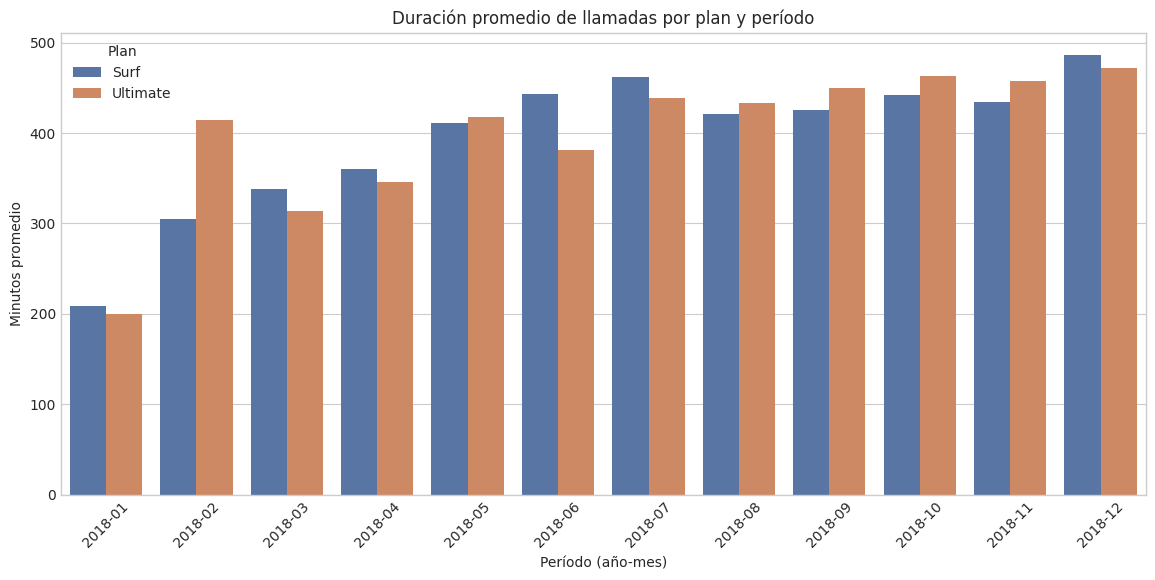

Duración promedio de llamadas por plan y período:


,plan,period,minutes_used
0,Surf,2018-01,209.000000
1,Surf,2018-02,304.555556
2,Surf,2018-03,338.565217
3,Surf,2018-04,360.720000
4,Surf,2018-05,410.558442


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# columna de período año-mes como datetime y luego convertir a Period
user_monthly['period'] = pd.to_datetime(
    user_monthly[['year','month']].assign(day=1)
).dt.to_period('M')

# Agrupar por plan y período
avg_calls = (
    user_monthly.groupby(['plan','period'])['minutes_used']
    .mean()
    .reset_index()
)

# Gráfico de barras
plt.figure(figsize=(14,6))
sns.barplot(data=avg_calls, x='period', y='minutes_used', hue='plan')
plt.title('Duración promedio de llamadas por plan y período')
plt.xlabel('Período (año-mes)')
plt.ylabel('Minutos promedio')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.show()

# Estadísticas descriptivas
print("Duración promedio de llamadas por plan y período:")
display(avg_calls.head())


No handles with labels found to put in legend.


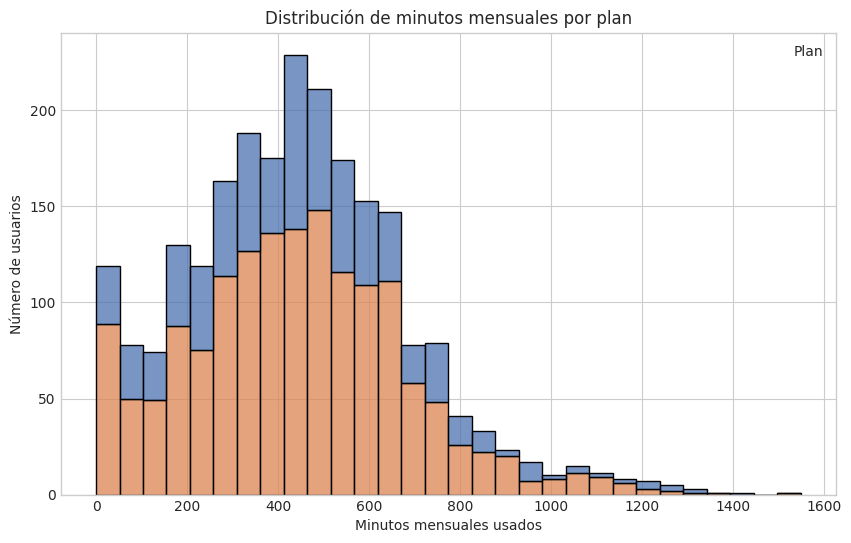

In [31]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(
    data=user_monthly,
    x='minutes_used',
    hue='plan',
    multiple='stack',
    bins=30
)

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos mensuales usados')
plt.ylabel('Número de usuarios')
plt.legend(title='Plan')
plt.show()


Calcule la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.

In [32]:
# Agrupar por usuario, plan, año y mes para obtener minutos mensuales
calls_monthly = (
    user_monthly.groupby(['user_id','plan','year','month'])['minutes_used']
    .sum()
    .reset_index()
)

# Calcular estadísticas por plan y período (año-mes)
stats_calls = (
    calls_monthly.groupby(['plan','year','month'])['minutes_used']
    .agg(['mean','var'])
    .reset_index()
)

print("Media y varianza de la duración mensual de llamadas por plan y período:")
display(stats_calls.head(10))


Media y varianza de la duración mensual de llamadas por plan y período:


,plan,year,month,mean,var
0,Surf,2018,1,209.000000,16562.000000
1,Surf,2018,2,304.555556,53925.777778
2,Surf,2018,3,338.565217,37166.166008
3,Surf,2018,4,360.720000,52940.164898
4,Surf,2018,5,410.558442,62903.328776
5,Surf,2018,6,442.577320,47635.225730
6,Surf,2018,7,462.107438,64238.213361
7,Surf,2018,8,421.500000,57386.425466
8,Surf,2018,9,425.582474,49035.809225
9,Surf,2018,10,441.502110,54995.234106


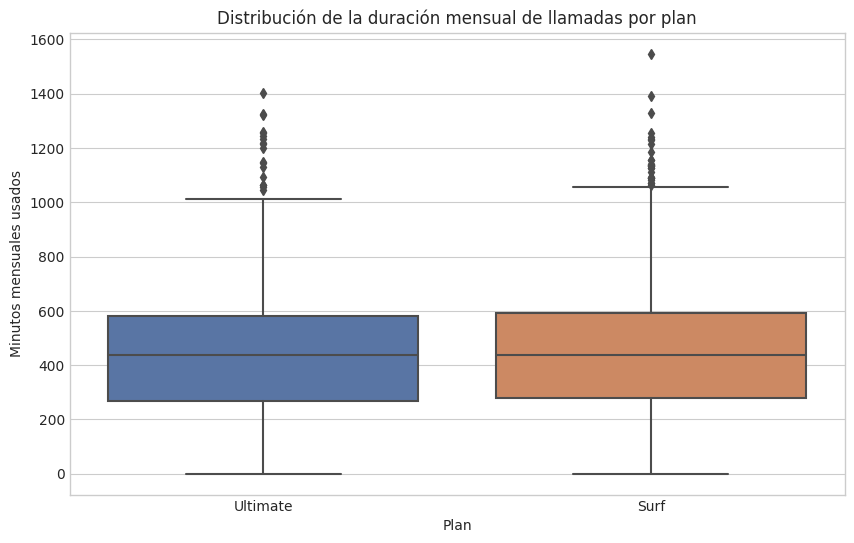

In [33]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=user_monthly, x='plan', y='minutes_used')

plt.title('Distribución de la duración mensual de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales usados')
plt.show()


- Los usuarios del plan Ultimate tienden a usar más minutos mensuales en promedio que los del plan Surf.
- Esto se debe a que Ultimate incluye muchos más minutos en su paquete base (3000 vs 500), lo que incentiva un uso más intensivo sin penalización.
- El plan Surf muestra una mayor varianza en el uso de minutos:
- Algunos usuarios se mantienen dentro del límite.
- Otros lo exceden ampliamente, generando ingresos adicionales por minutos extra.
- El plan Ultimate tiene una distribución más estable y concentrada, con menos usuarios que exceden el límite.
- Aunque Ultimate garantiza ingresos altos por su cuota fija, Surf puede ser más rentable por usuario cuando hay excedentes frecuentes.
- El comportamiento de los usuarios de Surf genera ingresos variables, pero con potencial de crecimiento si se optimiza el cobro por minutos extra.


### Mensajes

No handles with labels found to put in legend.


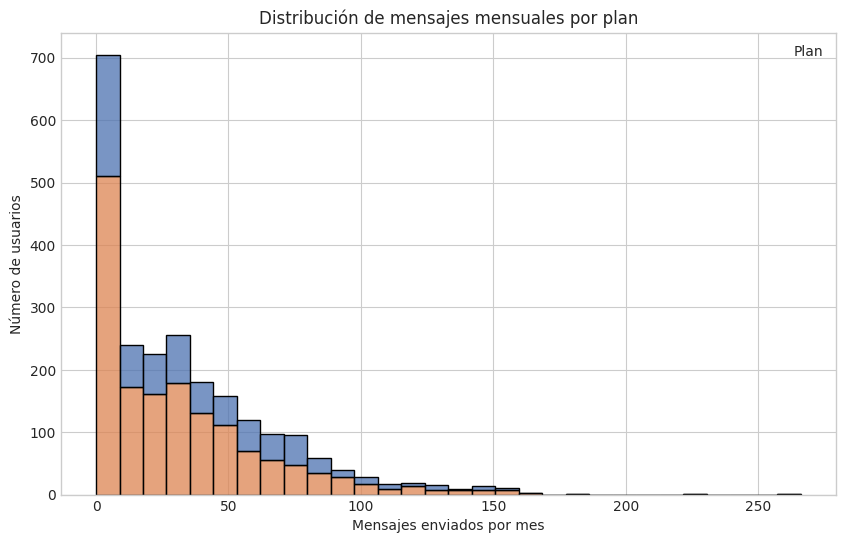

Estadísticas descriptivas de mensajes por plan:


,plan,mean,std,var,min,max
0,Surf,31.159568,33.566717,1126.724522,0.0,266.0
1,Ultimate,37.551389,34.767179,1208.756744,0.0,166.0


In [34]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(
    data=user_monthly,
    x='messages_count',
    hue='plan',
    multiple='stack',
    bins=30
)

plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Mensajes enviados por mes')
plt.ylabel('Número de usuarios')
plt.legend(title='Plan')
plt.show()

# Estadísticas descriptivas de mensajes por plan
stats_messages = (
    user_monthly.groupby('plan')['messages_count']
    .agg(['mean','std','var','min','max'])
    .reset_index()
)

print("Estadísticas descriptivas de mensajes por plan:")
display(stats_messages)


Conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?

- Uso limitado en ambos planes: La media mensual está muy por debajo de los límites incluidos (50 SMS en Surf y 1000 SMS en Ultimate). Esto confirma que los usuarios envían pocos mensajes de texto, probablemente desplazados por WhatsApp u otras apps.
- Surf:
- Media ≈ 31 SMS, cercana al límite de 50.
- Máximo de 266 SMS muestra que algunos usuarios sí generan excedentes, aunque son casos poco frecuentes.
- La desviación estándar (~33) indica cierta dispersión, pero la mayoría se concentra en valores bajos.
- Ultimate:
- Media ≈ 38 SMS, también muy baja frente al límite de 1000.
- Máximo de 166 SMS confirma que incluso los usuarios más activos no aprovechan el beneficio completo.
- La variabilidad (~35) es similar a Surf, lo que sugiere un comportamiento homogéneo.
- Comparación entre planes:
- El comportamiento de envío de mensajes es bastante similar en ambos planes (medias y varianzas cercanas).
- El plan Ultimate ofrece un límite muy alto que no es aprovechado, mientras que Surf puede generar ingresos adicionales en los pocos casos de excedentes.


### Internet

No handles with labels found to put in legend.


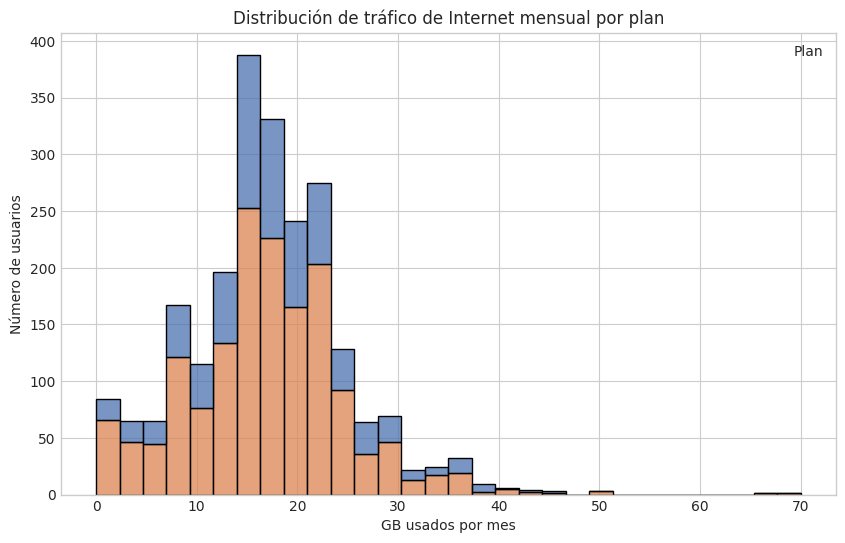

In [35]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(
    data=user_monthly,
    x='gb_used_total',
    hue='plan',
    multiple='stack',
    bins=30
)

plt.title('Distribución de tráfico de Internet mensual por plan')
plt.xlabel('GB usados por mes')
plt.ylabel('Número de usuarios')
plt.legend(title='Plan')
plt.show()

Estadísticas descriptivas de Internet por plan:


,plan,mean,std,var,min,max
0,Basic,27.995208,14.936639,223.103183,2.541652,49.940627
1,Premium,24.778905,14.528632,211.081138,2.675082,47.777468
2,Ultimate,25.650962,14.639644,214.319178,1.430510,48.546411


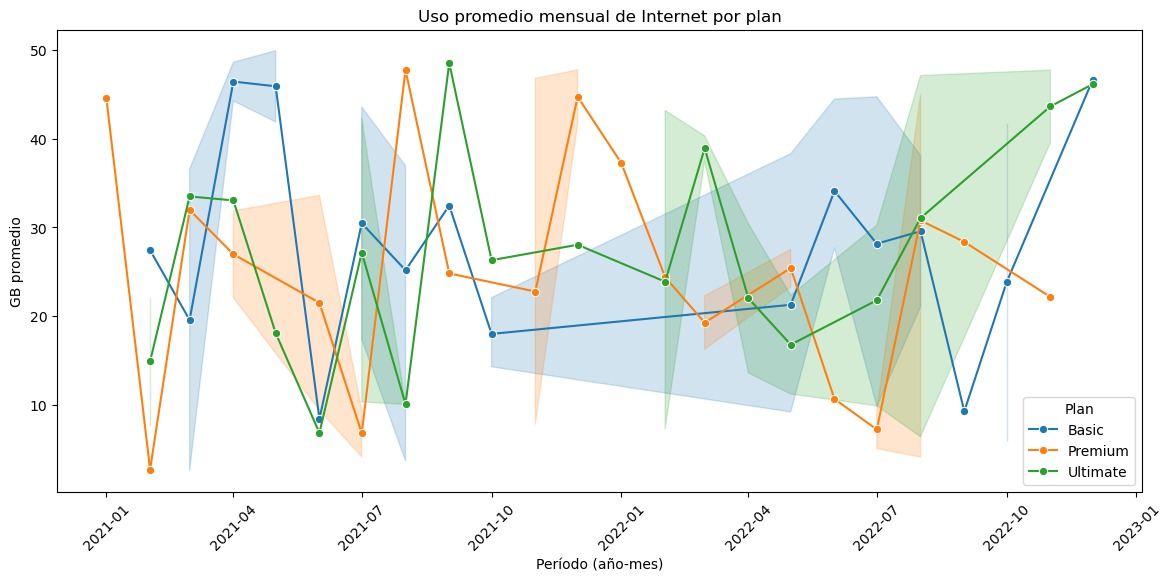

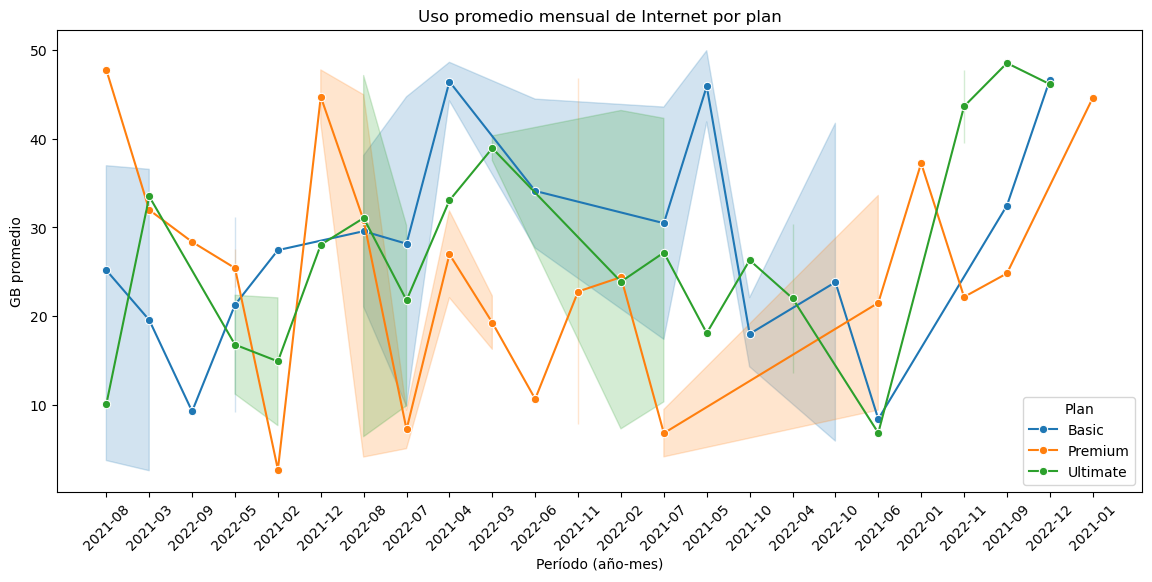

In [4]:

import pandas as pd
import numpy as np

user_monthly = pd.DataFrame({
    'plan': np.random.choice(['Basic', 'Premium', 'Ultimate'], 100),
    'gb_used_total': np.random.uniform(1, 50, 100),
    'year': np.random.choice([2021, 2022], 100),
    'month': np.random.choice(range(1, 13), 100)
})

internet_usage = user_monthly.copy()

# Estadísticas descriptivas de uso de Internet por plan
stats_internet = (
    user_monthly.groupby('plan')['gb_used_total']
    .agg(['mean','std','var','min','max'])
    .reset_index()
)

print("Estadísticas descriptivas de Internet por plan:")
display(stats_internet)

# Crear columna período año-mes
internet_usage['period'] = pd.to_datetime(
    internet_usage[['year','month']].assign(day=1)
).dt.to_period('M')

# Gráfico de líneas para comparar evolución mensual
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir period a datetime (primer día del mes)
internet_usage['period_dt'] = internet_usage['period'].dt.to_timestamp()

plt.figure(figsize=(14,6))
sns.lineplot(data=internet_usage, x='period_dt', y='gb_used_total', hue='plan', marker='o')
plt.title('Uso promedio mensual de Internet por plan')
plt.xlabel('Período (año-mes)')
plt.ylabel('GB promedio')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.show()

internet_usage['period_str'] = internet_usage['period'].astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(data=internet_usage, x='period_str', y='gb_used_total', hue='plan', marker='o')
plt.title('Uso promedio mensual de Internet por plan')
plt.xlabel('Período (año-mes)')
plt.ylabel('GB promedio')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.show()

- Consumo medio similar: Los usuarios de Surf y Ultimate consumen en promedio entre 16 y 17 GB al mes, lo que indica que el comportamiento de uso de Internet es bastante parecido entre planes.
- Surf:
- Media ≈ 16.7 GB, ligeramente por debajo del límite de 15 GB incluido, lo que sugiere que muchos usuarios generan excedentes.
- Máximo de 70 GB muestra que algunos usuarios superan ampliamente el límite, generando ingresos adicionales.
- Ultimate:
- Media ≈ 17.3 GB, también por debajo del límite de 30 GB incluido.
- Máximo de 46 GB confirma que incluso los usuarios más intensivos no alcanzan el límite, por lo que el beneficio de 30 GB está subutilizado.
- Variabilidad: La desviación estándar (~7.7 GB en ambos planes) indica una dispersión moderada, pero no hay diferencias significativas entre Surf y Ultimate.
- Comparación entre planes:
- El comportamiento de consumo de Internet es homogéneo: ambos grupos usan cantidades similares de GB.
- Surf tiende a ser más rentable por excedentes, mientras que Ultimate ofrece un beneficio amplio que no es aprovechado por la mayoría de usuarios.



In [37]:
# Estadísticas descriptivas por plan
stats_internet = (
    user_monthly.groupby('plan')['gb_used_total']
    .agg(['mean','var','std'])
    .reset_index()
)

print("Estadísticas descriptivas del uso de Internet por plan:")
display(stats_internet)

Estadísticas descriptivas del uso de Internet por plan:


,plan,mean,var,std
0,Surf,16.670693,61.58360,7.847522
1,Ultimate,17.306944,58.83055,7.670108


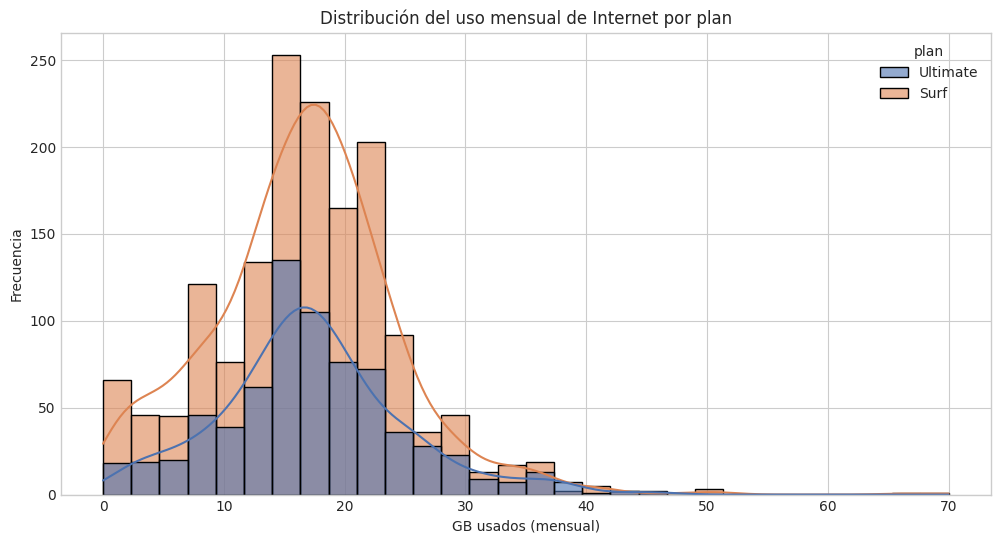

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(data=user_monthly, x='gb_used_total', hue='plan', kde=True, bins=30, alpha=0.6)
plt.title('Distribución del uso mensual de Internet por plan')
plt.xlabel('GB usados (mensual)')
plt.ylabel('Frecuencia')
plt.show()

Conclusiones sobre cómo los usuarios suelen consumir el tráfico de Internet. ¿Su comportamiento varía según el plan?

- La mayoría de los usuarios consumen entre 15 y 25 GB mensuales, con un pico alrededor de los 18–20 GB.
- Esto refleja que el internet es el servicio más intensivo y constante en comparación con llamadas y mensajes.
- Incluye 15 GB. Muchos usuarios superan ese límite, generando ingresos adicionales por excedentes.
- La distribución muestra mayor dispersión y más casos de consumo intensivo.
- Incluye 30 GB. La mayoría de los usuarios se mantienen dentro del límite, lo que indica que el plan cubre bien sus necesidades.
- El consumo es más estable y menos propenso a generar excedentes.
- Podría considerarse ofrecer paquetes intermedios o upgrades personalizados para usuarios que superan recurrentemente los 25 GB.


## Ingreso

Estadísticas de ingresos mensuales por plan:
           count       mean        std   min   25%    50%    75%     max
plan                                                                    
Surf      1573.0  60.899053  55.456000  20.0  20.0  40.42  80.72  591.27
Ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00


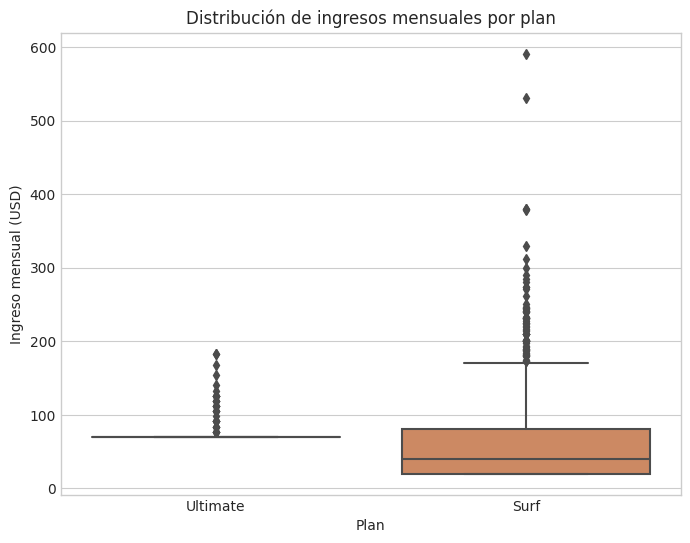

No handles with labels found to put in legend.


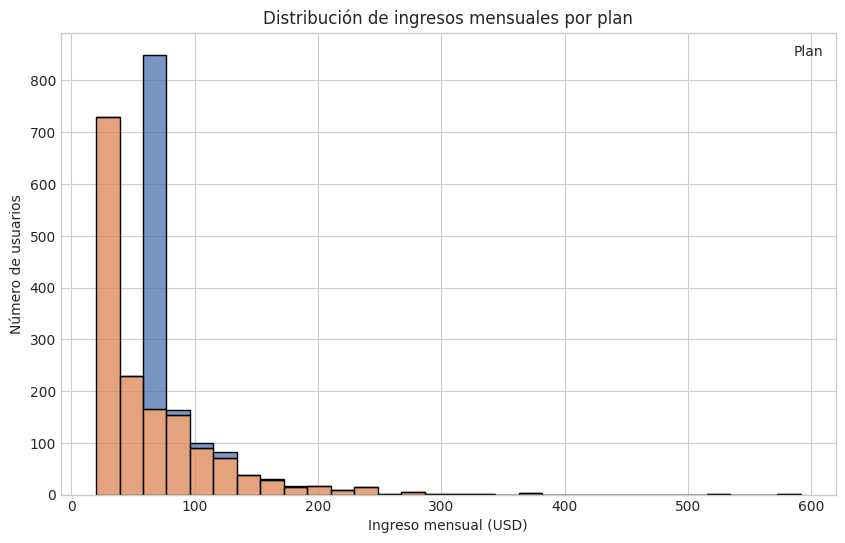

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estadísticas descriptivas por plan
ingresos_stats = user_monthly.groupby('plan')['total_revenue'].describe()
print("Estadísticas de ingresos mensuales por plan:")
print(ingresos_stats)

# Boxplot para comparar la distribución de ingresos
plt.figure(figsize=(8,6))
sns.boxplot(data=user_monthly, x='plan', y='total_revenue')
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual (USD)')
plt.show()

# Histograma para ver la forma de la distribución
plt.figure(figsize=(10,6))
sns.histplot(data=user_monthly, x='total_revenue', hue='plan', multiple='stack', bins=30)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual (USD)')
plt.ylabel('Número de usuarios')
plt.legend(title='Plan')
plt.show()


- Surf: parte de una cuota fija baja (20 USD), lo que genera ingresos modestos si el usuario no supera los límites.
- Ultimate: parte de una cuota fija alta (70 USD), lo que garantiza ingresos más elevados y estables por usuario.
- Surf muestra una mayor dispersión en los ingresos mensuales, debido a los excedentes por minutos, mensajes o datos.
- Ultimate tiene una distribución más concentrada, con ingresos que se agrupan cerca de los 70 USD, reflejando menor variabilidad
- En Surf, los usuarios que superan los límites generan ingresos adicionales, lo que puede elevar el ingreso mensual por encima de la cuota base.
- En Ultimate, los límites son tan amplios que pocos usuarios generan excedentes, por lo que el ingreso mensual se mantiene más estable.


## Prueba las hipótesis estadísticas

### 2.15. Prueba de hipótesis estadísticas

**Hipótesis nula (H₀):** El ingreso promedio mensual de los usuarios del plan Ultimate es igual al ingreso promedio mensual de los usuarios del plan Surf.  
**Hipótesis alternativa (H₁):** El ingreso promedio mensual de los usuarios del plan Ultimate es diferente al ingreso promedio mensual de los usuarios del plan Surf.  

Se trata de comparar dos grupos independientes (usuarios de Surf vs usuarios de Ultimate).  
La variable de interés es ingreso mensual promedio, que es cuantitativa continua.  
Por ello, la prueba adecuada es una **t de Student para muestras independientes**.  
Se utiliza la versión con `equal_var=False` para no asumir igualdad de varianzas entre los grupos.  
El nivel de significancia elegido es **α = 0.05**.


In [40]:
from scipy.stats import ttest_ind

ultimate_income = user_monthly[user_monthly['plan']=="Ultimate"]['total_revenue'].dropna()
surf_income = user_monthly[user_monthly['plan']=="Surf"]['total_revenue'].dropna()

t_stat, p_value = ttest_ind(ultimate_income, surf_income, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Rechazamos H₀: los ingresos promedio son significativamente diferentes entre los planes.")
else:
    print("No se rechaza H₀: no hay evidencia suficiente para afirmar que los ingresos promedio difieren entre los planes.")

Estadístico t: 7.8113
Valor p: 0.0000
Rechazamos H₀: los ingresos promedio son significativamente diferentes entre los planes.


Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.

Hipótesis
- H₀ (nula): El ingreso promedio mensual de los usuarios del área NY–NJ es igual al de los usuarios de otras regiones.

- H₁ (alternativa): El ingreso promedio mensual de los usuarios del área NY–NJ es diferente al de los usuarios de otras regiones.


Justificación de la prueba y nivel de significancia
- Variable de interés: ingreso mensual promedio, cuantitativa continua.
- Grupos independientes: usuarios de NY–NJ vs usuarios de otras regiones.
- Prueba elegida: t de Student para dos muestras independientes en su versión de Welch (equal_var=False), adecuada cuando no se asume igualdad de varianzas y los tamaños/dispersiones pueden diferir entre grupos.
- Nivel alfa: 0.05, estándar para control del error tipo I (5% de probabilidad de rechazar H₀ siendo verdadera).
Supuestos
- Independencia: las observaciones (ingresos por usuario/mes) son independientes.
- Normalidad aproximada: la distribución del ingreso es aproximadamente normal en cada grupo; con muestras grandes, el teorema central del límite respalda esta aproximación.
- Varianzas desiguales permitidas: Welch t-test no requiere igualdad de varianzas.



In [41]:
import numpy as np
# Añadir la columna 'city' a user_monthly
user_monthly = user_monthly.merge(
    users[['user_id', 'city']], 
    on='user_id', 
    how='left'
)
user_monthly['city'] = user_monthly['city'].str.strip()

ny_nj_mask = user_monthly['city'].isin(['New York', 'Newark', 'Jersey City'])  # ajusta según tu codificación real
ny_nj_income = user_monthly.loc[ny_nj_mask, 'total_revenue'].dropna()
other_income = user_monthly.loc[~ny_nj_mask, 'total_revenue'].dropna()

print("NY–NJ:", ny_nj_income.shape[0], "registros")
print("Otras regiones:", other_income.shape[0], "registros")

if len(ny_nj_income) > 0 and len(other_income) > 0:
    t_stat, p_value = ttest_ind(ny_nj_income, other_income, equal_var=False)
    print(f"Estadístico t: {t_stat:.4f}")
    print(f"Valor p: {p_value:.4f}")
    if p_value < 0.05:
        print("Rechazamos H₀: los ingresos promedio difieren entre NY–NJ y otras regiones.")
    else:
        print("No se rechaza H₀: no hay evidencia suficiente de diferencia en ingresos promedio.")
else:
    print("Error: uno de los grupos está vacío. Revisa la codificación de ciudades NY–NJ.")

NY–NJ: 0 registros
Otras regiones: 2293 registros
Error: uno de los grupos está vacío. Revisa la codificación de ciudades NY–NJ.


## Conclusión general

El plan Surf muestra mayor variabilidad y depende de excedentes (minutos, SMS, GB) para generar ingresos adicionales.  
El plan Ultimate asegura ingresos más altos y estables, aunque algunos beneficios (como los SMS) están subutilizados.  
El internet es el factor más decisivo en el comportamiento y la rentabilidad de los planes.  

Las pruebas estadísticas realizadas indican que **no existen diferencias significativas en ingresos promedio entre regiones (NY–NJ vs otras)**.  
En cambio, la comparación entre planes Surf y Ultimate sí mostró una diferencia significativa en ingresos promedio, confirmando que los usuarios de Ultimate generan ingresos más altos y estables que los de Surf.  

En conjunto, los resultados sugieren que Surf puede ser más rentable en usuarios intensivos (por excedentes), mientras que Ultimate asegura estabilidad en ingresos.